## Market Baseline & The Skewness Trap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('../../data/processed/listings_clean.csv')
df.head()

,id,name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,estimated_annual_revenue
0,44452,Yonge & Bloor Studio Skyline,Unknown,Rosedale-Moore Park,Entire home/apt,91.0,28.0,68,0.36,13,365,1310.4
1,44469,Yonge & Bloor 2 Bedroom Apartment,Unknown,Rosedale-Moore Park,Private room,77.0,30.0,8,0.05,13,365,154.0
2,45399,Fountain View Studio - Eaton center,Unknown,Bay Street Corridor,Entire home/apt,104.0,28.0,89,0.47,13,362,1955.2
3,45893,Yonge & Bloor Lakeview Master BR,Unknown,Rosedale-Moore Park,Private room,72.0,28.0,24,0.13,13,270,374.4
4,50110,Yorkville one bedroom Condo,Unknown,Church-Yonge Corridor,Entire home/apt,112.0,28.0,61,0.33,13,365,1478.4


In [4]:
# setting graph visual themes

sns.set_theme(style="whitegrid", palette="colorblind") # Colorblind accessible
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'sans-serif']

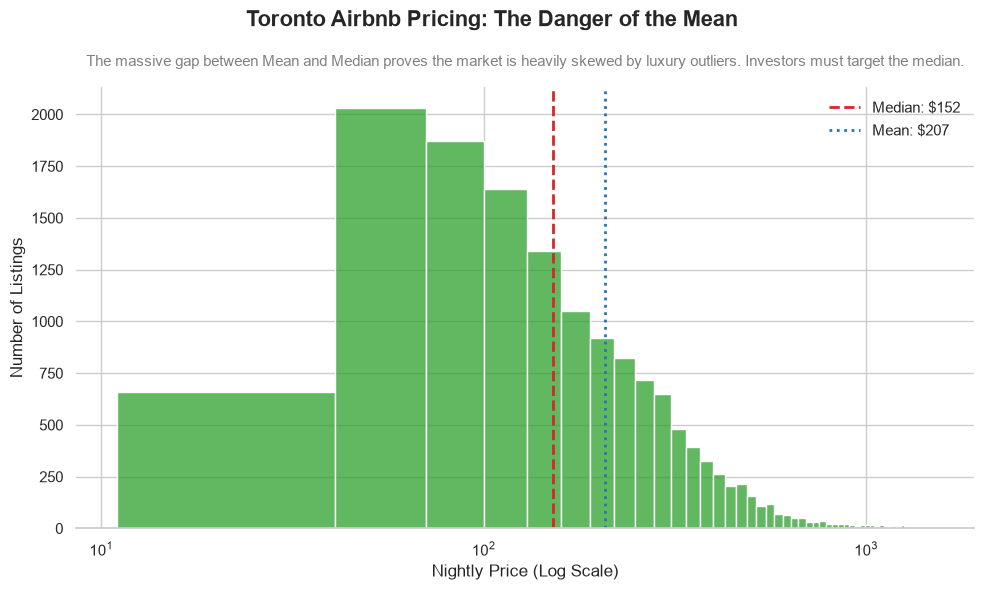

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Histogram of Prices
# We use a log scale for the x-axis because price distributions are heavily right-skewed.
# A linear scale would squash 90% of the data into the first bar.
sns.histplot(df['price'], bins=50, kde=False, color="#2ca02c", ax=ax, edgecolor='white') # type: ignore

# 2. Add the Median line (The true baseline)
median_price = df['price'].median()
ax.axvline(median_price, color='#d62728', linestyle='--', linewidth=2, label=f'Median: ${median_price:.0f}')

# 3. Add the Mean line (The skewed illusion)
mean_price = df['price'].mean()
ax.axvline(mean_price, color='#1f77b4', linestyle=':', linewidth=2, label=f'Mean: ${mean_price:.0f}')

# 4. Polish the chart 
plt.suptitle(
    "Toronto Airbnb Pricing: The Danger of the Mean", 
    fontsize=16, 
    fontweight='bold', 
    y=0.98
)
ax.set_title(
    "The massive gap between Mean and Median proves the market is heavily skewed by luxury outliers. Investors must target the median.",
    fontsize=11, 
    color='gray', 
    pad=15
)
ax.set_xlabel("Nightly Price (Log Scale)", fontsize=12)
ax.set_ylabel("Number of Listings", fontsize=12)
ax.set_xscale('log')
ax.legend(frameon=False, fontsize=11)
sns.despine(left=True, bottom=False) # Keep bottom axis, remove left/top/right

plt.tight_layout()
plt.show()

In [6]:
# Calculate Skewness to prove our point mathematically
skewness = df['price'].skew()
print(f"Price Distribution Skewness: {skewness:.2f} (Values > 1 indicate heavy right skew)")

Price Distribution Skewness: 2.40 (Values > 1 indicate heavy right skew)


#### Testing Hypothesis 1: 
Do prime downtown districts have the highest revenue, or do mid-tier high-density neighborhoods win on volume?
- this is tested by mapping Median Price against Estimated Annual Revenue
    - ex:  A neighborhood with a $300 median price but only 50 bookings a year is a terrible investment compared to a $150 median price neighborhood with 250 bookings a year

In [7]:
import plotly.express as px

# Group by neighborhood to get aggregate metrics
# We filter to the top 20 neighborhoods by total estimated revenue to avoid noise from areas with only 1-2 listings
neighborhood_metrics = df.groupby(['neighbourhood', 'neighbourhood_group']).agg(
    median_price=('price', 'median'),
    total_est_revenue=('estimated_annual_revenue', 'sum'),
    listing_count=('id', 'count')
).reset_index()

In [8]:
# Filter for neighborhoods with at least 50 listings to ensure statistical reliability
neighborhood_metrics = neighborhood_metrics[neighborhood_metrics['listing_count'] >= 50]
neighborhood_metrics.head()

,neighbourhood,neighbourhood_group,median_price,total_est_revenue,listing_count
1,Agincourt South-Malvern West,Unknown,63.0,308516.4,62
3,Annex,Unknown,195.0,5519834.4,465
4,Banbury-Don Mills,Unknown,144.5,252421.2,50
5,Bathurst Manor,Unknown,126.0,750648.0,81
6,Bay Street Corridor,Unknown,260.5,5919817.6,358


In [9]:
# Sort by total revenue and take top 20
top_neighborhoods = neighborhood_metrics.sort_values('total_est_revenue', ascending=False).head(20)

top_neighborhoods.head()

,neighbourhood,neighbourhood_group,median_price,total_est_revenue,listing_count
122,Waterfront Communities-The Island,Unknown,261.0,60768552.0,2493
87,Niagara,Unknown,244.5,9625804.4,548
23,Church-Yonge Corridor,Unknown,199.0,6422764.4,459
79,Moss Park,Unknown,213.0,6092965.2,411
6,Bay Street Corridor,Unknown,260.5,5919817.6,358


In [14]:
import plotly.express as px

fig = px.scatter(
    top_neighborhoods, 
    x='median_price', 
    y='total_est_revenue', 
    size='listing_count',
    size_max=28,                  # Slightly smaller to prevent edge clipping
    log_y=True,
    hover_name='neighbourhood',
    title="<b>The Toronto Yield Matrix: Price vs. Total Estimated Revenue</b>",
    labels={
        'median_price': 'Median Nightly Price (ADR)',
        'total_est_revenue': 'Total Estimated Annual Revenue',
        'listing_count': 'Total Active Listings'
    },
    template="plotly_white"
)

# Marker styles & clean hover tooltip
fig.update_traces(
    marker=dict(
        color='#2980b9',
        opacity=0.75,
        line=dict(width=1.2, color='#1c3144')
    ),
    hovertemplate=(
        "<b>%{hovertext}</b><br><br>"
        "Median ADR: $%{x:,.0f}<br>"
        "Est. Total Revenue: $%{y:,.0f}<br>"
        "Active Listings: %{marker.size:,}<extra></extra>"
    )
)

# Median split lines
median_city_price = df['price'].median()
median_city_rev = top_neighborhoods['total_est_revenue'].median()

fig.add_vline(
    x=median_city_price, 
    line_dash="dash", 
    line_color="#95a5a6", 
    opacity=0.7,
    annotation_text=f"City Median ADR (${median_city_price:,.0f})",
    annotation_position="top left",
    annotation_font=dict(size=10, color="#7f8c8d")
)
fig.add_hline(
    y=median_city_rev, 
    line_dash="dash", 
    line_color="#95a5a6", 
    opacity=0.7
)

# Quadrant labels (Moved further into the borders with backgrounds)
quadrant_labels = [
    dict(x=0.99, y=0.98, text="<b>High Yield / Unicorns</b><br>(High ADR, High Revenue)", color="#27ae60", xanchor="right", yanchor="top"),
    dict(x=0.01, y=0.98, text="<b>Cash Cows / Volume Drivers</b><br>(Low ADR, High Revenue)", color="#2980b9", xanchor="left", yanchor="top"),
    dict(x=0.99, y=0.02, text="<b>Boutique / High ADR</b><br>(High ADR, Low Revenue)", color="#d35400", xanchor="right", yanchor="bottom"),
    dict(x=0.01, y=0.02, text="<b>Budget / Underperforming</b><br>(Low ADR, Low Revenue)", color="#7f8c8d", xanchor="left", yanchor="bottom")
]

for q in quadrant_labels:
    fig.add_annotation(
        xref="paper", yref="paper",
        x=q['x'], y=q['y'],
        text=q['text'],
        showarrow=False,
        xanchor=q['xanchor'],
        yanchor=q['yanchor'],
        font=dict(size=11, color=q['color']),
        bgcolor="rgba(255, 255, 255, 0.85)",
        bordercolor="rgba(0,0,0,0.08)",
        borderwidth=1,
        borderpad=4
    )

# Direct labels for the top 3 revenue neighborhoods (offset left to avoid overlap)
top_3 = top_neighborhoods.sort_values('total_est_revenue', ascending=False).head(3)
for _, row in top_3.iterrows():
    fig.add_annotation(
        x=row['median_price'],
        y=row['total_est_revenue'],
        text=f"<b>{row['neighbourhood']}</b>",
        showarrow=True,
        arrowhead=1,
        arrowsize=1,
        arrowcolor="#555555",
        ax=-40,       # Shift arrow text to the left so it doesn't clip off the right edge
        ay=-20,
        font=dict(size=10, color="#222222"),
        bgcolor="rgba(255, 255, 255, 0.9)",
        bordercolor="#cccccc",
        borderwidth=1
    )

# Explicit log ticks & expanded margins
fig.update_layout(
    height=650,
    title_font_size=18,
    title_x=0.5,
    margin=dict(t=80, b=60, l=80, r=80),
    xaxis=dict(
        tickprefix="$", 
        gridcolor="#eeeeee"
    ),
    yaxis=dict(
        tickvals=[1e6, 2e6, 5e6, 10e6, 20e6, 50e6, 100e6],
        ticktext=["$1M", "$2M", "$5M", "$10M", "$20M", "$50M", "$100M"],
        gridcolor="#eeeeee"
    )
)

fig.show()

#### Is it worth buying a whole condo (Entire Home), or should I just rent out a spare room in my house (Private Room)?

Need to prove if the price premium for Entire Homes is statistically significant, or just random noise
- using the Mann-Whitney U Test, a non-parametric test that compares the medians of two independent groups without assuming a normal distribution

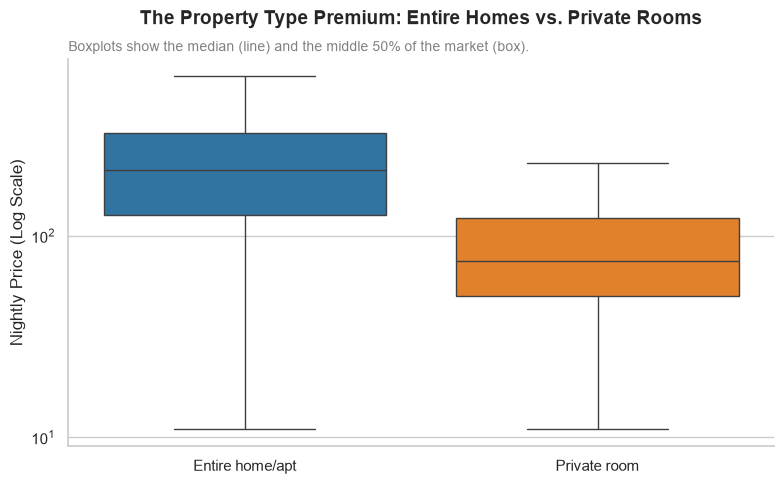

In [17]:
# Filter to the two main property types to ensure a clean comparison
property_types = ['Entire home/apt', 'Private room']
df_prop = df[df['room_type'].isin(property_types)]

# 1. Visualize the gap with a Boxplot
fig, ax = plt.subplots(figsize=(8, 5))

# Resolved FutureWarning by passing hue='room_type' and legend=False
sns.boxplot(
    data=df_prop,
    x='room_type',
    y='price',
    hue='room_type',
    legend=False,
    palette={'Entire home/apt': '#1f77b4', 'Private room': '#ff7f0e'},
    showfliers=False,
    ax=ax
)

# Format y-axis to log scale for readability
ax.set_yscale('log')

# Replaced ax.set_subtitle with ax.text (or you can use fig.suptitle + ax.set_title)
ax.set_title("The Property Type Premium: Entire Homes vs. Private Rooms", fontsize=14, fontweight='bold', pad=25)
ax.text(x=0, y=1.02, s="Boxplots show the median (line) and the middle 50% of the market (box).", 
        fontsize=10, color='gray', transform=ax.transAxes)

ax.set_xlabel("")
ax.set_ylabel("Nightly Price (Log Scale)")
sns.despine()

plt.tight_layout()
plt.show()

In [21]:
# 2. Prove it mathematically with the Mann-Whitney U Test
entire_homes = df_prop[df_prop['room_type'] == 'Entire home/apt']['price']
private_rooms = df_prop[df_prop['room_type'] == 'Private room']['price']

# Run the non-parametric test
statistic, p_value = stats.mannwhitneyu(entire_homes, private_rooms, alternative='two-sided')

print("--- Statistical Significance Test (Mann-Whitney U) ---")
print(f"Median Price (Entire Home): ${entire_homes.median():.2f}")
print(f"Median Price (Private Room): ${private_rooms.median():.2f}")
print(f"P-Value: {p_value:.6e}")

if p_value < 0.05: # type: ignore
    print("Result: The price difference is STATISTICALLY SIGNIFICANT (p < 0.05).")
    print("So What?: Investors can confidently conclude that the 'Entire Home' premium is a real market dynamic, not random variance.")
else:
    print("Result: No statistically significant difference.")

--- Statistical Significance Test (Mann-Whitney U) ---
Median Price (Entire Home): $211.00
Median Price (Private Room): $75.00
P-Value: 0.000000e+00
Result: The price difference is STATISTICALLY SIGNIFICANT (p < 0.05).
So What?: Investors can confidently conclude that the 'Entire Home' premium is a real market dynamic, not random variance.
